<a href="https://colab.research.google.com/github/kec9308/hw1/blob/main/bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install transformers datasets scikit-learn pandas torch

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('processed_tweets.csv')           # has cleaned text + tweeti

In [ ]:
df.columns

Index(['sentiment', 'message', 'tweetid', 'cleaned_message',
       'processed_message'],
      dtype='object')

In [ ]:
df.head()

,sentiment,message,tweetid,cleaned_message,processed_message
0,-1,@tiniebeany climate change is an interesting h...,792927353886371840,climate change is an interesting hustle as it...,climat chang interest hustl global warm planet...
1,1,RT @NatGeoChannel: Watch #BeforeTheFlood right...,793124211518832641,": Watch #BeforeTheFlood right here, as travel...",watch beforetheflood right travel world tackl ...
2,1,Fabulous! Leonardo #DiCaprio's film on #climat...,793124402388832256,Fabulous! Leonardo #DiCaprio's film on #climat...,fabul leonardo dicaprio 's film climat chang b...
3,1,RT @Mick_Fanning: Just watched this amazing do...,793124635873275904,: Just watched this amazing documentary by leo...,watch amaz documentari leonardodicaprio climat...
4,2,"RT @cnalive: Pranita Biswasi, a Lutheran from ...",793125156185137153,": Pranita Biswasi, a Lutheran from Odisha, giv...",pranita biswasi lutheran odisha give testimoni...


In [ ]:
df = df[['cleaned_message', 'sentiment']]
df = df.rename(columns={'cleaned_message': 'text', 'sentiment': 'label'})

print("Label categories:", df['label'].unique())
# Split the data




Label categories: [-1  1  2  0]


In [ ]:
df.head()

,text,label
0,climate change is an interesting hustle as it...,-1
1,": Watch #BeforeTheFlood right here, as travel...",1
2,Fabulous! Leonardo #DiCaprio's film on #climat...,1
3,: Just watched this amazing documentary by leo...,1
4,": Pranita Biswasi, a Lutheran from Odisha, giv...",2


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)


## Tokenizing Tweets using BERT

In [ ]:
from transformers import BertModel, BertTokenizer

bert_model = BertModel.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

bert_model.eval() # setting it to evaluation mode

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [12]:
import torch
from torch.utils.data import DataLoader

#getting the embeddings

def get_embeddings_batch(texts, batch_size=32):
    embeddings = []

    # Create a simple DataLoader
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, texts):
            self.texts = texts

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            return self.texts[idx]

    dataset = SimpleDataset(texts)
    loader = DataLoader(dataset, batch_size=batch_size)

    bert_model.eval()

    with torch.no_grad():
        for batch_texts in loader:
            # Tokenize the entire batch
            inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128)
            outputs = bert_model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # Grab [CLS] embeddings
            embeddings.append(cls_embeddings)

    # Stack all the batches into one big tensor
    embeddings = torch.cat(embeddings, dim=0)
    return embeddings.numpy()




train_embeddings = get_embeddings_batch(train_texts, batch_size=32)
val_embeddings = get_embeddings_batch(val_texts, batch_size=32)



## Logistic Regression

In [74]:
accuracies ={}
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(train_embeddings, train_labels)


LogisticRegression(max_iter=1000)

In [75]:
#evaluate
val_preds = clf.predict(val_embeddings)
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(val_labels, val_preds, target_names=["Anti", "Neutral", "Pro", "News"]))
acc = accuracy_score(val_labels, val_preds)
print(f"Overall Accuracy: {acc*100:.2f}%")
accuracies["Logistic Regression"] = acc

              precision    recall  f1-score   support

        Anti       0.54      0.35      0.43       784
     Neutral       0.60      0.43      0.50      1582
         Pro       0.71      0.82      0.76      4514
        News       0.72      0.73      0.73      1909

    accuracy                           0.69      8789
   macro avg       0.64      0.58      0.60      8789
weighted avg       0.68      0.69      0.68      8789

Overall Accuracy: 68.80%


In [76]:
print(accuracies)

{'Logistic Regression': 0.6880191148025941}


## XGBoost

In [77]:
pip install xgboost

In [78]:
import xgboost as xgb
from xgboost import XGBClassifier

#fixing the input to nums >= 0 so the classifier can work
train_labels_fixed = [label + 1 for label in train_labels]


xgb_clf = XGBClassifier(
    objective='multi:softprob',     # for multiclass classification
    num_class=4,                    # 4 labels: Anti, Neutral, Pro, News
    eval_metric='mlogloss',         # multiclass log-loss
    use_label_encoder=False,        # to avoid warning
    n_jobs=-1,                      # use all CPU cores
    max_depth=6,                    # control model complexity
    learning_rate=0.1,              # step size
    n_estimators=100                # number of boosting rounds (trees)
)

#training the model
xgb_clf.fit(train_embeddings, train_labels_fixed)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:24:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_class=4, num_parallel_tree=None, ...)

In [79]:
val_preds = xgb_clf.predict(val_embeddings)

# subtract 1 back to compare properly
val_preds_original = [pred - 1 for pred in val_preds]


In [80]:
from sklearn.metrics import classification_report, accuracy_score

# 5. Print classification report
print(classification_report(val_labels, val_preds_original, target_names=["Anti", "Neutral", "Pro", "News"]))

# 6. Print overall accuracy separately
acc = accuracy_score(val_labels, val_preds_original)
print(f"Overall Accuracy: {acc*100:.2f}%")

accuracies["XGBoost"] = acc

              precision    recall  f1-score   support

        Anti       0.62      0.15      0.25       784
     Neutral       0.65      0.37      0.47      1582
         Pro       0.68      0.89      0.77      4514
        News       0.75      0.72      0.73      1909

    accuracy                           0.69      8789
   macro avg       0.68      0.53      0.55      8789
weighted avg       0.69      0.69      0.66      8789

Overall Accuracy: 69.15%


In [81]:
print(accuracies)

{'Logistic Regression': 0.6880191148025941, 'XGBoost': 0.6915462509955627}


In [82]:
# TODO Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
randomforest = RandomForestClassifier(n_estimators=100, random_state=23)
randomforest.fit(train_embeddings, train_labels)
val_preds = randomforest.predict(val_embeddings)
print(classification_report(val_labels, val_preds_original, target_names=["Anti", "Neutral", "Pro", "News"]))
accuracy = accuracy_score(val_labels, val_preds)
accuracies["Random Forest"] = accuracy
print(f"Overall Accuracy: {accuracy*100:.2f}%")


              precision    recall  f1-score   support

        Anti       0.62      0.15      0.25       784
     Neutral       0.65      0.37      0.47      1582
         Pro       0.68      0.89      0.77      4514
        News       0.75      0.72      0.73      1909

    accuracy                           0.69      8789
   macro avg       0.68      0.53      0.55      8789
weighted avg       0.69      0.69      0.66      8789

Overall Accuracy: 66.91%


In [83]:
print(accuracies)

{'Logistic Regression': 0.6880191148025941, 'XGBoost': 0.6915462509955627, 'Random Forest': 0.6691318693821823}


MSE: 0.47300058603286743
R-squared: 0.35564959049224854


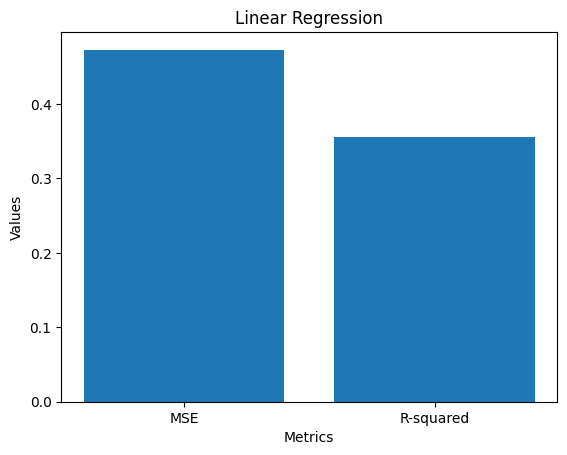

In [84]:
##linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report,mean_squared_error
lin_reg = LinearRegression()
lin_reg.fit(train_embeddings, train_labels)
val_preds = lin_reg.predict(val_embeddings)
#print(classification_report(val_labels, val_preds_original, target_names=["Anti", "Neutral", "Pro", "News"]))
mse = mean_squared_error(val_labels, val_preds)
rsq = lin_reg.score(val_embeddings, val_labels)
print("MSE:", mse)
print("R-squared:", rsq)
metrics = {"MSE": mse, "R-squared": rsq}
plt.bar(metrics.keys(),metrics.values())
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Linear Regression")
plt.show()
#accuracies["Linear Regression"] = accuracy
#print(f"Overall Accuracy: {accuracy*100:.2f}%")


In [85]:
print(accuracies)

{'Logistic Regression': 0.6880191148025941, 'XGBoost': 0.6915462509955627, 'Random Forest': 0.6691318693821823}


In [86]:
accuracies_2 = accuracies.copy()
print(accuracies_2)

{'Logistic Regression': 0.6880191148025941, 'XGBoost': 0.6915462509955627, 'Random Forest': 0.6691318693821823}


dict_keys(['Logistic Regression', 'XGBoost', 'Random Forest'])


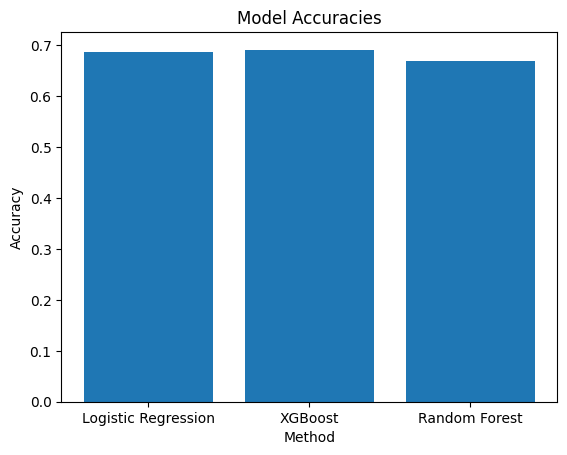

In [89]:
# TODO Create diagrams, charts, and figures.
import matplotlib.pyplot as plt
import numpy as np
print(accuracies.keys())
methods = list(accuracies.keys())
accuracies = list(accuracies.values())
plt.bar(methods,accuracies)
plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("Model Accuracies")
plt.show()